In [ ]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
    
from dotenv import load_dotenv

load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [15]:
class BatsmanState(TypedDict):

    #input
    total_runs: int
    four: int
    sixes: int
    balls: int

    #calculated
    SR: float
    boundary_runs: int
    boundary_counts: int
    boundary_percentage: float
    boundary_frequency: float
    summary: str

In [24]:
def boundary_calc(state: BatsmanState):

    counts = state['four'] + state['sixes']
    runs = 4*state['four'] + 6*state['sixes']

    return {
        "boundary_counts":counts,
        "boundary_runs": runs
    }

def sr_calc(state: BatsmanState):

    sr = round((state['boundary_runs']/state['balls'])*100,2)
    return {
        "SR": sr
    }

def boundary_percent(state: BatsmanState):

    bp = round((state['boundary_runs']/state['total_runs'])*100,2)
    return {
        "boundary_percentage": bp
    }

def boundary_freq(state: BatsmanState):

    bf = round((state['balls']/state['boundary_counts']),2)
    return {
        "boundary_frequency": bf
    }

def summary(state: BatsmanState) -> BatsmanState:

    q = f"""
    Generate a short professional cricket summary using these stats:

    Total Runs: {state['total_runs']}
    Balls: {state['balls']}
    Strike Rate: {state.get('SR')}
    Boundary Runs: {state.get('boundary_runs')}
    Boundary Percentage: {state.get('boundary_percentage')}
    Boundary Frequency: {state.get('boundary_frequency')}
    """
    
    summary = llm.invoke(q).content

    return {
        "summary": summary
    }


In [25]:
graph = StateGraph(BatsmanState)

#nodes
graph.add_node('boundary_calc', boundary_calc)
graph.add_node('sr_calc', sr_calc)
graph.add_node('boundary_percent', boundary_percent)
graph.add_node('boundary_freq', boundary_freq)
graph.add_node('summary', summary)
#edges
graph.add_edge(START, 'boundary_calc')

graph.add_edge('boundary_calc','sr_calc' )
graph.add_edge('boundary_calc','boundary_percent')
graph.add_edge('boundary_calc', 'boundary_freq')

graph.add_edge('sr_calc', 'summary')
graph.add_edge('boundary_percent', 'summary')
graph.add_edge('boundary_freq', 'summary')

graph.add_edge('summary',END)

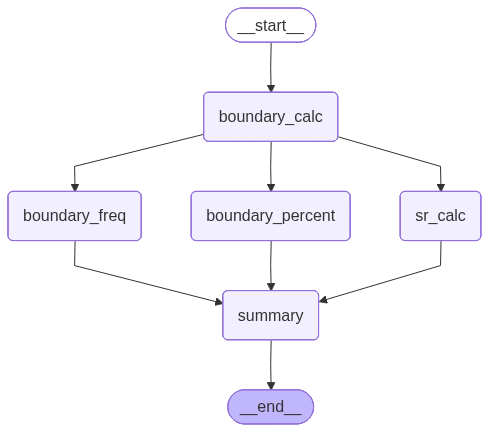

In [26]:
workflow = graph.compile()
workflow

In [29]:
initial_state = {
    'total_runs':77,
    'four':10,
    'sixes':3,
    'balls':40,
}

output_state = workflow.invoke(initial_state)

In [ ]:
display(Markdown(output_state["summary"]))

Here's a short professional cricket summary based on those stats:

An explosive innings saw the batsman score **77 runs off just 40 balls**, demonstrating a formidable strike rate of **145.0**. The bulk of these runs, a staggering **58**, came from boundaries, accounting for **75.32%** of the total. A boundary was struck with remarkable regularity, approximately every **3.08 balls**, highlighting a dominant, boundary-laden approach.